# Image Denoising Using Spatial Filtering Techniques

### Digital Image Processing Mini Project

This project studies image denoising using spatial filtering techniques.
Gaussian noise and salt-and-pepper noise are added artificially to
original images. Mean, median, and Gaussian filters are then applied
to reduce the noise.

The performance of the filtering techniques is evaluated using:
- Mean Squared Error (MSE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index (SSIM)

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving img2.jpeg to img2.jpeg
Saving img3.jpeg to img3.jpeg
Saving img1.jpeg to img1.jpeg


In [3]:
image_name = list(uploaded.keys())[0]

image = cv2.imread(image_name)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize image
image_rgb = cv2.resize(image_rgb, (512, 512))

print("Image loaded successfully")
print("Image shape:", image_rgb.shape)

Image loaded successfully
Image shape: (512, 512, 3)


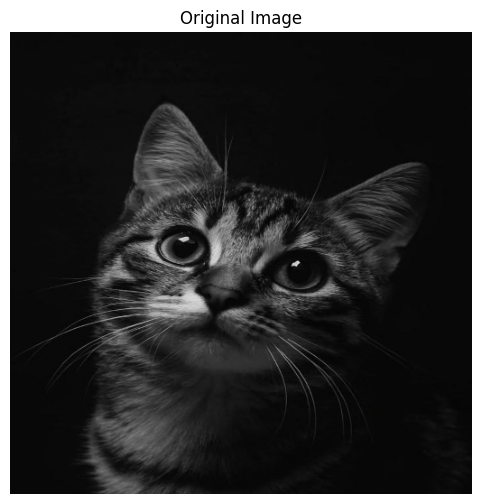

In [4]:
plt.figure(figsize=(6, 6))

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.show()

## Adding Gaussian Noise

Gaussian noise is random noise that follows a Gaussian distribution.
It can occur due to electronic sensor noise and other image acquisition
conditions.

In this project, Gaussian noise is artificially added to the original
image so that different filtering techniques can be tested.

In [5]:
def add_gaussian_noise(image, mean=0, sigma=25):
    image_float = image.astype(np.float32)

    noise = np.random.normal(mean, sigma, image.shape)

    noisy_image = image_float + noise

    noisy_image = np.clip(noisy_image, 0, 255)

    return noisy_image.astype(np.uint8)


gaussian_noisy = add_gaussian_noise(image_rgb)

print("Gaussian noise added successfully")

Gaussian noise added successfully


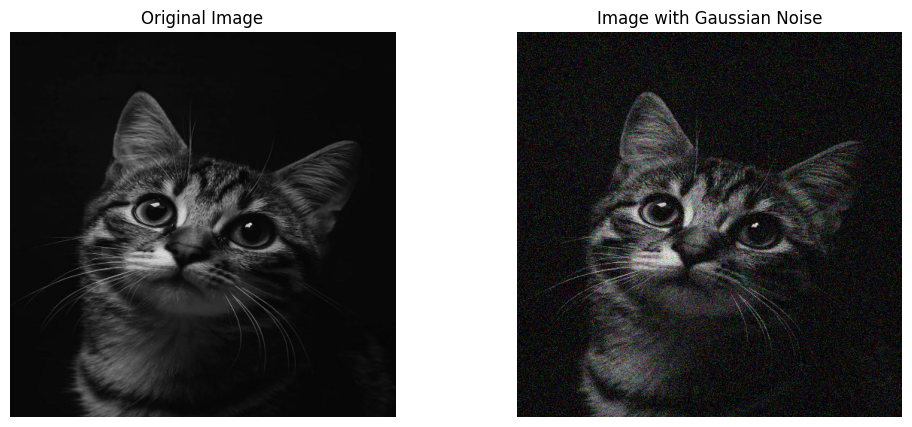

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gaussian_noisy)
plt.title("Image with Gaussian Noise")
plt.axis("off")

plt.show()

## Adding Salt-and-Pepper Noise

Salt-and-pepper noise appears as random white and black pixels in an
image.

In this project, salt-and-pepper noise is artificially added to the
original image to test the performance of different filters.

In [7]:
def add_salt_pepper_noise(image, amount=0.05):
    noisy_image = image.copy()

    total_pixels = image.shape[0] * image.shape[1]

    number_of_pixels = int(amount * total_pixels)

    # Salt noise
    for _ in range(number_of_pixels // 2):
        y = np.random.randint(0, image.shape[0])
        x = np.random.randint(0, image.shape[1])

        noisy_image[y, x] = 255

    # Pepper noise
    for _ in range(number_of_pixels // 2):
        y = np.random.randint(0, image.shape[0])
        x = np.random.randint(0, image.shape[1])

        noisy_image[y, x] = 0

    return noisy_image


sp_noisy = add_salt_pepper_noise(image_rgb)

print("Salt-and-pepper noise added successfully")

Salt-and-pepper noise added successfully


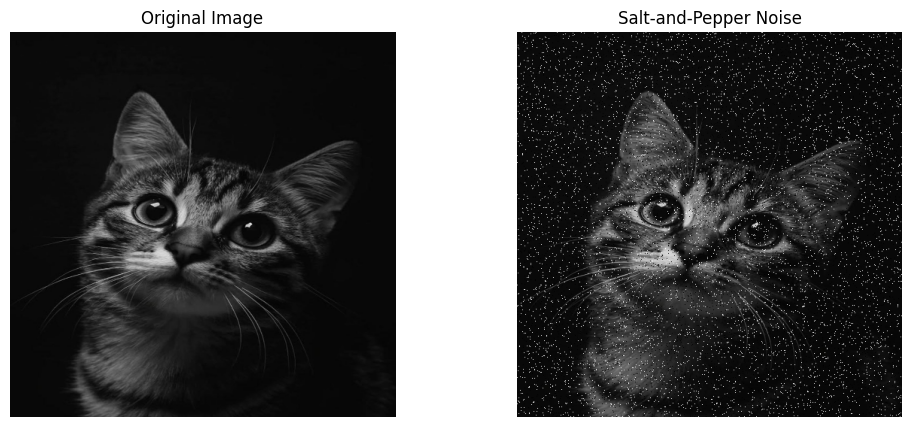

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sp_noisy)
plt.title("Salt-and-Pepper Noise")
plt.axis("off")

plt.show()

## Mean Filtering

Mean filtering replaces each pixel with the average value of
neighboring pixels.

It can reduce random noise, but excessive smoothing may remove
important image details.

In [9]:
mean_gaussian = cv2.blur(gaussian_noisy, (5, 5))
mean_sp = cv2.blur(sp_noisy, (5, 5))

print("Mean filtering completed")

Mean filtering completed


## Median Filtering

Median filtering replaces a pixel with the median value of its
neighboring pixels.

It is particularly useful for removing salt-and-pepper noise.

In [10]:
median_gaussian = cv2.medianBlur(gaussian_noisy, 5)
median_sp = cv2.medianBlur(sp_noisy, 5)

print("Median filtering completed")

Median filtering completed


## Gaussian Filtering

Gaussian filtering smooths an image using a Gaussian kernel.

It is commonly used to reduce noise while producing smoother
image results.

In [11]:
gaussian_filter_gaussian = cv2.GaussianBlur(
    gaussian_noisy, (5, 5), 0
)

gaussian_filter_sp = cv2.GaussianBlur(
    sp_noisy, (5, 5), 0
)

print("Gaussian filtering completed")

Gaussian filtering completed


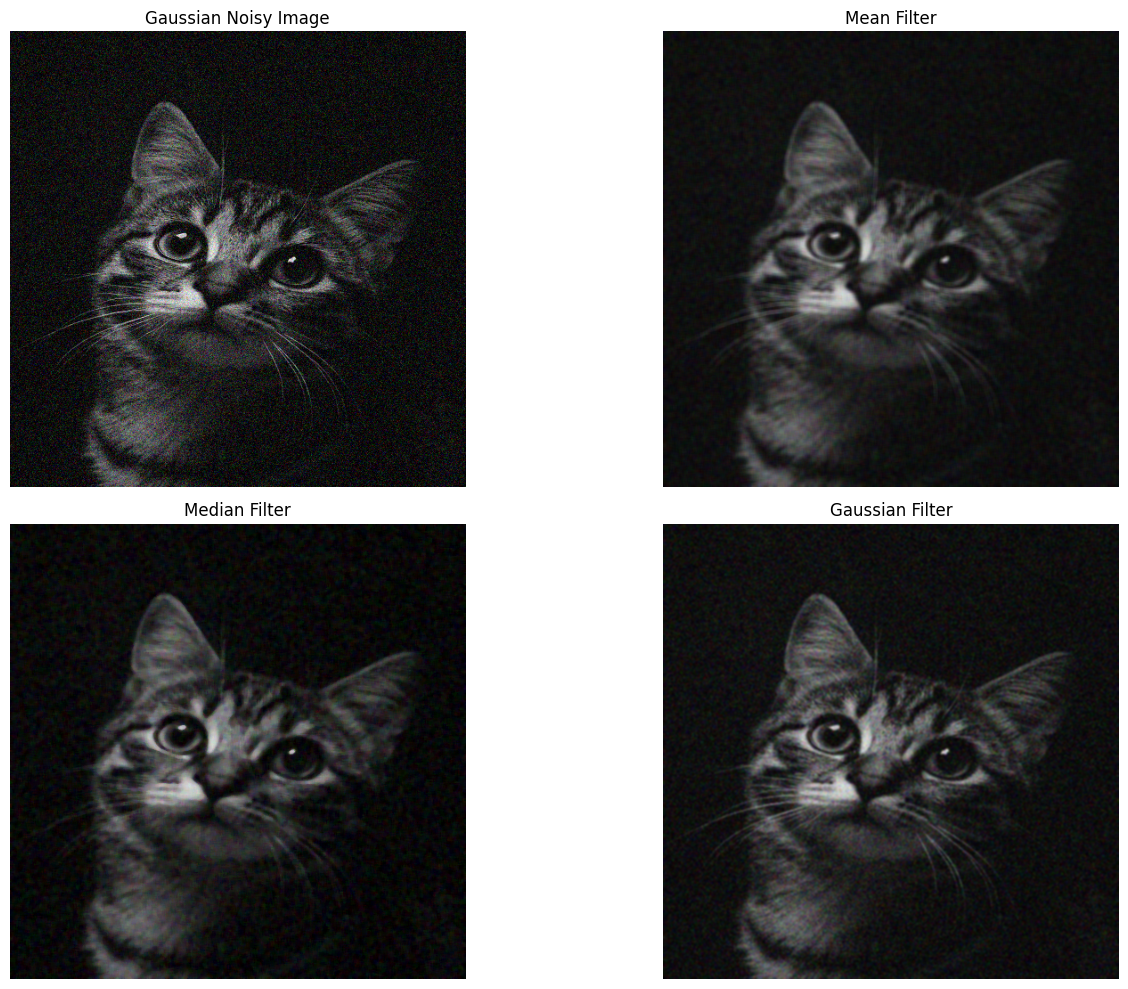

In [12]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(gaussian_noisy)
plt.title("Gaussian Noisy Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mean_gaussian)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median_gaussian)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_filter_gaussian)
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

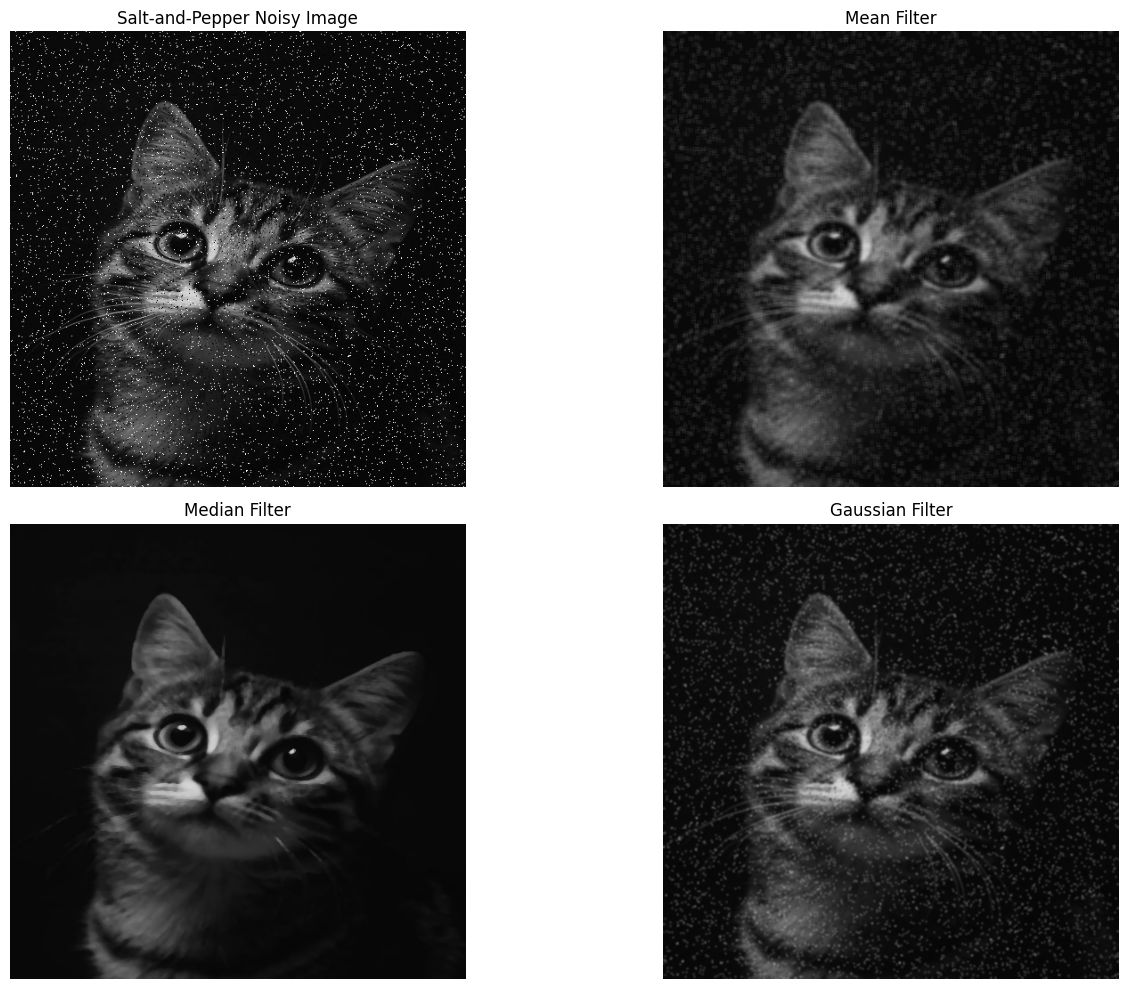

In [13]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(sp_noisy)
plt.title("Salt-and-Pepper Noisy Image")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(mean_sp)
plt.title("Mean Filter")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(median_sp)
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(gaussian_filter_sp)
plt.title("Gaussian Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

## Evaluation Metrics

The restoration results are evaluated using:

### MSE
Mean Squared Error measures the average squared difference between
the original image and the restored image.

Lower MSE indicates less error.

### PSNR
Peak Signal-to-Noise Ratio measures the quality of the restored image.

Higher PSNR generally indicates better restoration quality.

### SSIM
Structural Similarity Index measures similarity in structural
information between the original and restored images.

A value closer to 1 indicates greater structural similarity.

In [14]:
def calculate_metrics(original, restored):

    original_float = original.astype(np.float32)
    restored_float = restored.astype(np.float32)

    mse_value = np.mean(
        (original_float - restored_float) ** 2
    )

    psnr_value = psnr(
        original,
        restored,
        data_range=255
    )

    ssim_value = ssim(
        original,
        restored,
        channel_axis=2,
        data_range=255
    )

    return mse_value, psnr_value, ssim_value

In [15]:
results_gaussian = []

filters_gaussian = {
    "Mean Filter": mean_gaussian,
    "Median Filter": median_gaussian,
    "Gaussian Filter": gaussian_filter_gaussian
}

for filter_name, result in filters_gaussian.items():

    mse_value, psnr_value, ssim_value = calculate_metrics(
        image_rgb,
        result
    )

    results_gaussian.append([
        "Gaussian Noise",
        filter_name,
        mse_value,
        psnr_value,
        ssim_value
    ])


df_gaussian = pd.DataFrame(
    results_gaussian,
    columns=[
        "Noise Type",
        "Filter",
        "MSE",
        "PSNR",
        "SSIM"
    ]
)

df_gaussian

,Noise Type,Filter,MSE,PSNR,SSIM
0,Gaussian Noise,Mean Filter,91.749573,28.504763,0.730328
1,Gaussian Noise,Median Filter,89.184418,28.627914,0.653464
2,Gaussian Noise,Gaussian Filter,83.373390,28.920529,0.695605


In [16]:
results_sp = []

filters_sp = {
    "Mean Filter": mean_sp,
    "Median Filter": median_sp,
    "Gaussian Filter": gaussian_filter_sp
}

for filter_name, result in filters_sp.items():

    mse_value, psnr_value, ssim_value = calculate_metrics(
        image_rgb,
        result
    )

    results_sp.append([
        "Salt-and-Pepper Noise",
        filter_name,
        mse_value,
        psnr_value,
        ssim_value
    ])


df_sp = pd.DataFrame(
    results_sp,
    columns=[
        "Noise Type",
        "Filter",
        "MSE",
        "PSNR",
        "SSIM"
    ]
)

df_sp

,Noise Type,Filter,MSE,PSNR,SSIM
0,Salt-and-Pepper Noise,Mean Filter,135.495346,26.811560,0.590868
1,Salt-and-Pepper Noise,Median Filter,52.607132,30.920358,0.894152
2,Salt-and-Pepper Noise,Gaussian Filter,158.942108,26.118415,0.539166


In [17]:
all_results = pd.concat(
    [df_gaussian, df_sp],
    ignore_index=True
)

all_results

,Noise Type,Filter,MSE,PSNR,SSIM
0,Gaussian Noise,Mean Filter,91.749573,28.504763,0.730328
1,Gaussian Noise,Median Filter,89.184418,28.627914,0.653464
2,Gaussian Noise,Gaussian Filter,83.373390,28.920529,0.695605
3,Salt-and-Pepper Noise,Mean Filter,135.495346,26.811560,0.590868
4,Salt-and-Pepper Noise,Median Filter,52.607132,30.920358,0.894152
5,Salt-and-Pepper Noise,Gaussian Filter,158.942108,26.118415,0.539166


In [18]:
print("Best filter for Gaussian Noise based on PSNR:")

best_gaussian = df_gaussian.loc[
    df_gaussian["PSNR"].idxmax()
]

print(best_gaussian)


print("\nBest filter for Salt-and-Pepper Noise based on PSNR:")

best_sp = df_sp.loc[
    df_sp["PSNR"].idxmax()
]

print(best_sp)

Best filter for Gaussian Noise based on PSNR:
Noise Type     Gaussian Noise
Filter        Gaussian Filter
MSE                  83.37339
PSNR                28.920529
SSIM                 0.695605
Name: 2, dtype: object

Best filter for Salt-and-Pepper Noise based on PSNR:
Noise Type    Salt-and-Pepper Noise
Filter                Median Filter
MSE                       52.607132
PSNR                      30.920358
SSIM                       0.894152
Name: 1, dtype: object


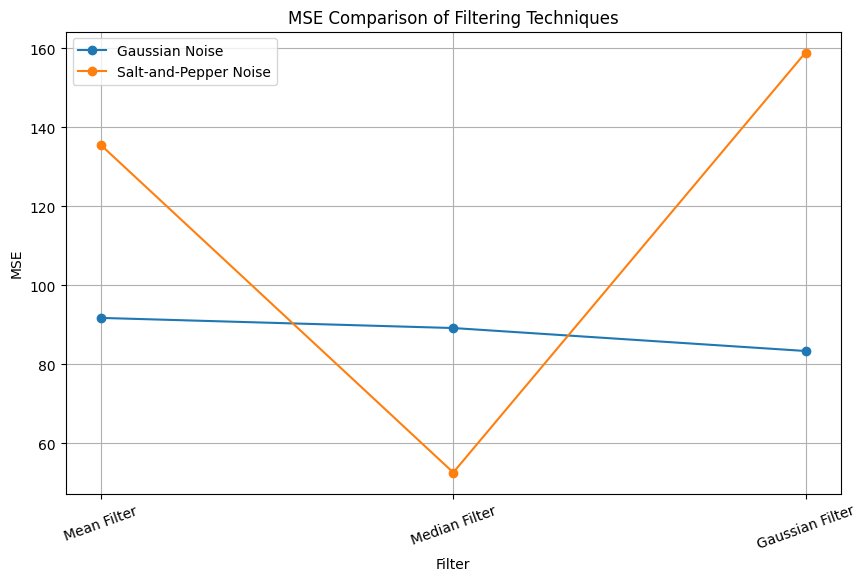

In [19]:
plt.figure(figsize=(10, 6))

for noise_type in all_results["Noise Type"].unique():

    data = all_results[
        all_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["MSE"],
        marker="o",
        label=noise_type
    )

plt.title("MSE Comparison of Filtering Techniques")
plt.xlabel("Filter")
plt.ylabel("MSE")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

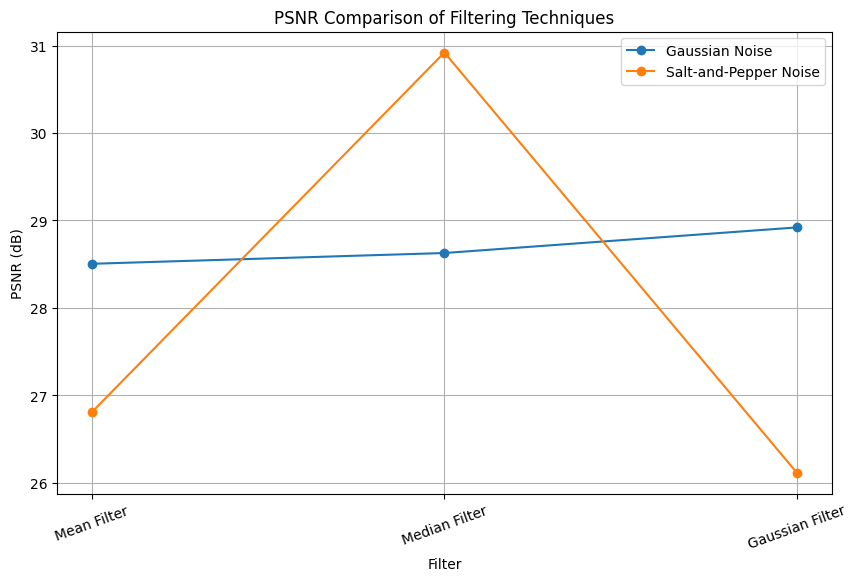

In [20]:
plt.figure(figsize=(10, 6))

for noise_type in all_results["Noise Type"].unique():

    data = all_results[
        all_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["PSNR"],
        marker="o",
        label=noise_type
    )

plt.title("PSNR Comparison of Filtering Techniques")
plt.xlabel("Filter")
plt.ylabel("PSNR (dB)")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

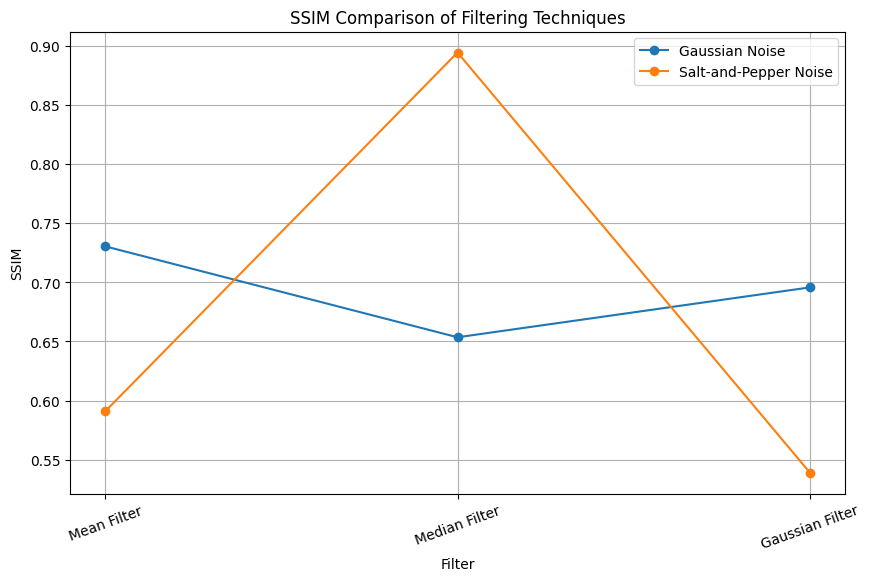

In [21]:
plt.figure(figsize=(10, 6))

for noise_type in all_results["Noise Type"].unique():

    data = all_results[
        all_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["SSIM"],
        marker="o",
        label=noise_type
    )

plt.title("SSIM Comparison of Filtering Techniques")
plt.xlabel("Filter")
plt.ylabel("SSIM")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

In [22]:
all_results.to_csv(
    "denoising_results.csv",
    index=False
)

print("Results saved as denoising_results.csv")

Results saved as denoising_results.csv


In [23]:
from google.colab import files

files.download("denoising_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

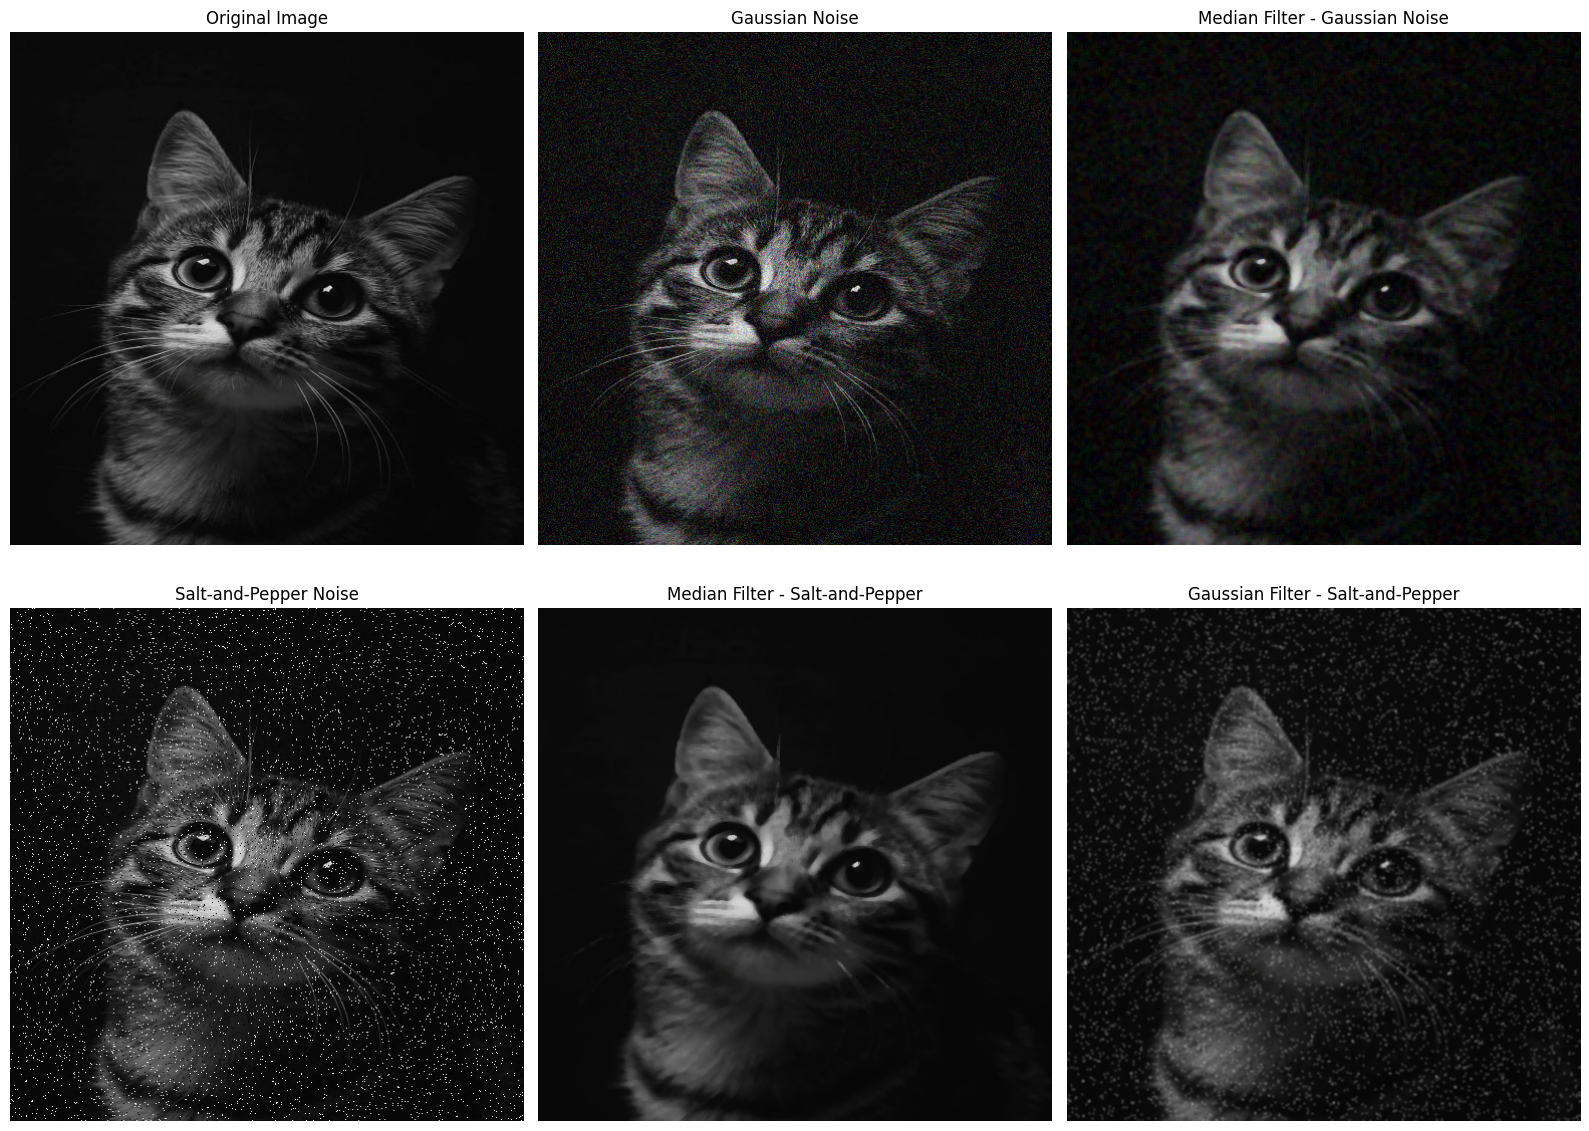

In [24]:
plt.figure(figsize=(16, 12))

images = [
    image_rgb,
    gaussian_noisy,
    median_gaussian,
    sp_noisy,
    median_sp,
    gaussian_filter_sp
]

titles = [
    "Original Image",
    "Gaussian Noise",
    "Median Filter - Gaussian Noise",
    "Salt-and-Pepper Noise",
    "Median Filter - Salt-and-Pepper",
    "Gaussian Filter - Salt-and-Pepper"
]

for i in range(len(images)):

    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Processing Multiple Images

The previous section demonstrated the denoising process using one image.

In this section, the same experiment is performed on all uploaded images.
The results from all images are collected and averaged to provide a
more reliable comparison of the different filtering techniques.

In [25]:
# ==========================================
# PROCESS ALL UPLOADED IMAGES
# ==========================================

all_image_results = []

for image_name in uploaded.keys():

    print("Processing:", image_name)

    # Read image
    image = cv2.imread(image_name)

    if image is None:
        print("Could not read:", image_name)
        continue

    # Convert BGR to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image_rgb = cv2.resize(image_rgb, (512, 512))

    # --------------------------------------
    # ADD NOISE
    # --------------------------------------

    gaussian_noisy = add_gaussian_noise(
        image_rgb,
        mean=0,
        sigma=25
    )

    sp_noisy = add_salt_pepper_noise(
        image_rgb,
        amount=0.05
    )

    # --------------------------------------
    # GAUSSIAN NOISE - FILTERING
    # --------------------------------------

    mean_gaussian = cv2.blur(
        gaussian_noisy,
        (5, 5)
    )

    median_gaussian = cv2.medianBlur(
        gaussian_noisy,
        5
    )

    gaussian_filter_gaussian = cv2.GaussianBlur(
        gaussian_noisy,
        (5, 5),
        0
    )

    # --------------------------------------
    # SALT-AND-PEPPER NOISE - FILTERING
    # --------------------------------------

    mean_sp = cv2.blur(
        sp_noisy,
        (5, 5)
    )

    median_sp = cv2.medianBlur(
        sp_noisy,
        5
    )

    gaussian_filter_sp = cv2.GaussianBlur(
        sp_noisy,
        (5, 5),
        0
    )

    # --------------------------------------
    # STORE RESULTS
    # --------------------------------------

    filtered_images = {
        "Gaussian Noise": {
            "Mean Filter": mean_gaussian,
            "Median Filter": median_gaussian,
            "Gaussian Filter": gaussian_filter_gaussian
        },

        "Salt-and-Pepper Noise": {
            "Mean Filter": mean_sp,
            "Median Filter": median_sp,
            "Gaussian Filter": gaussian_filter_sp
        }
    }

    # --------------------------------------
    # CALCULATE METRICS
    # --------------------------------------

    for noise_type, filters in filtered_images.items():

        for filter_name, restored_image in filters.items():

            mse_value, psnr_value, ssim_value = calculate_metrics(
                image_rgb,
                restored_image
            )

            all_image_results.append([
                image_name,
                noise_type,
                filter_name,
                mse_value,
                psnr_value,
                ssim_value
            ])


print("\nProcessing completed!")
print("Total results:", len(all_image_results))

Processing: img2.jpeg
Processing: img3.jpeg
Processing: img1.jpeg

Processing completed!
Total results: 18


In [26]:
# ==========================================
# CREATE RESULTS DATAFRAME
# ==========================================

all_image_results_df = pd.DataFrame(
    all_image_results,
    columns=[
        "Image",
        "Noise Type",
        "Filter",
        "MSE",
        "PSNR",
        "SSIM"
    ]
)

all_image_results_df

,Image,Noise Type,Filter,MSE,PSNR,SSIM
0,img2.jpeg,Gaussian Noise,Mean Filter,91.765083,28.504029,0.730301
1,img2.jpeg,Gaussian Noise,Median Filter,89.073280,28.633329,0.652738
2,img2.jpeg,Gaussian Noise,Gaussian Filter,83.459373,28.916053,0.694887
3,img2.jpeg,Salt-and-Pepper Noise,Mean Filter,134.551392,26.841922,0.593615
4,img2.jpeg,Salt-and-Pepper Noise,Median Filter,52.552555,30.924864,0.894328
5,img2.jpeg,Salt-and-Pepper Noise,Gaussian Filter,156.906418,26.174397,0.543736
6,img3.jpeg,Gaussian Noise,Mean Filter,63.361130,30.112573,0.775206
7,img3.jpeg,Gaussian Noise,Median Filter,74.495827,29.409484,0.700853
8,img3.jpeg,Gaussian Noise,Gaussian Filter,64.463799,30.037644,0.701230
9,img3.jpeg,Salt-and-Pepper Noise,Mean Filter,94.220741,28.389338,0.701373


In [27]:
# ==========================================
# AVERAGE RESULTS
# ==========================================

average_results = (
    all_image_results_df
    .groupby(["Noise Type", "Filter"])[
        ["MSE", "PSNR", "SSIM"]
    ]
    .mean()
    .reset_index()
)

# Round values for easier presentation
average_results["MSE"] = average_results["MSE"].round(2)
average_results["PSNR"] = average_results["PSNR"].round(2)
average_results["SSIM"] = average_results["SSIM"].round(4)

average_results

,Noise Type,Filter,MSE,PSNR,SSIM
0,Gaussian Noise,Gaussian Filter,82.540001,29.03,0.7102
1,Gaussian Noise,Mean Filter,91.800003,28.65,0.7505
2,Gaussian Noise,Median Filter,98.080002,28.34,0.6844
3,Salt-and-Pepper Noise,Gaussian Filter,136.119995,26.83,0.6135
4,Salt-and-Pepper Noise,Mean Filter,124.919998,27.24,0.6635
5,Salt-and-Pepper Noise,Median Filter,57.549999,30.88,0.8937


In [28]:
# ==========================================
# SAVE FINAL RESULTS
# ==========================================

average_results.to_csv(
    "final_average_results.csv",
    index=False
)

all_image_results_df.to_csv(
    "all_image_results.csv",
    index=False
)

print("Final result files created:")
print("1. final_average_results.csv")
print("2. all_image_results.csv")

Final result files created:
1. final_average_results.csv
2. all_image_results.csv


In [29]:
# ==========================================
# DOWNLOAD RESULTS
# ==========================================

from google.colab import files

files.download("final_average_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
files.download("all_image_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Final Comparison of Filtering Techniques

The average performance of the filtering techniques is compared using
MSE, PSNR, and SSIM across all images in the dataset.

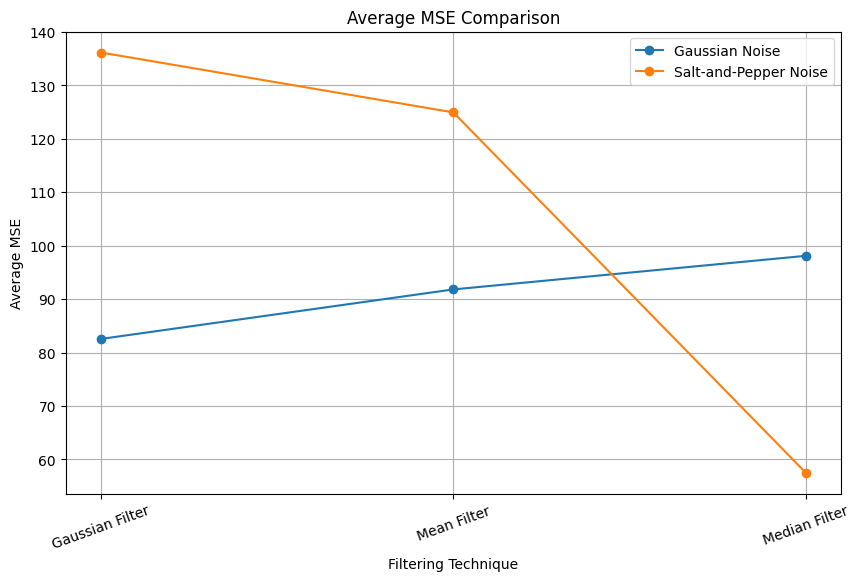

In [31]:
# ==========================================
# FINAL MSE COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

for noise_type in average_results["Noise Type"].unique():

    data = average_results[
        average_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["MSE"],
        marker="o",
        label=noise_type
    )

plt.title("Average MSE Comparison")
plt.xlabel("Filtering Technique")
plt.ylabel("Average MSE")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

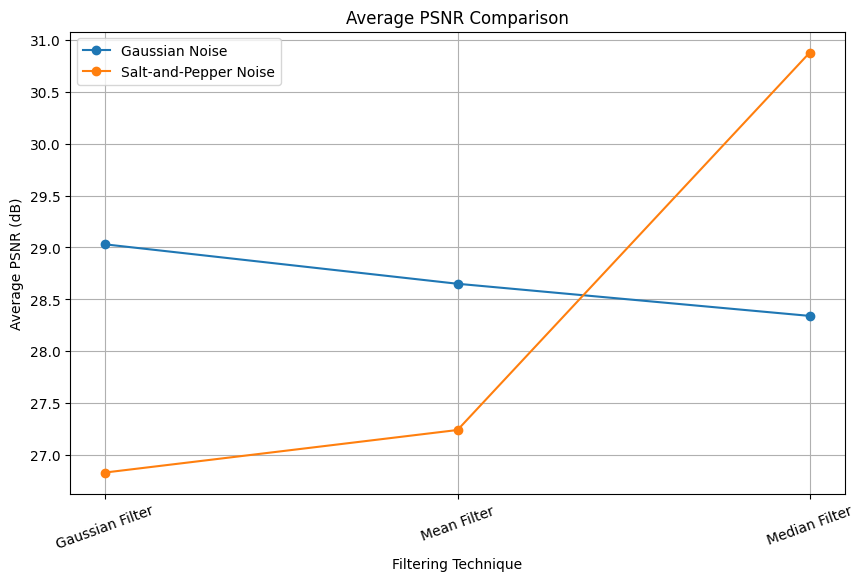

In [32]:
# ==========================================
# FINAL PSNR COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

for noise_type in average_results["Noise Type"].unique():

    data = average_results[
        average_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["PSNR"],
        marker="o",
        label=noise_type
    )

plt.title("Average PSNR Comparison")
plt.xlabel("Filtering Technique")
plt.ylabel("Average PSNR (dB)")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

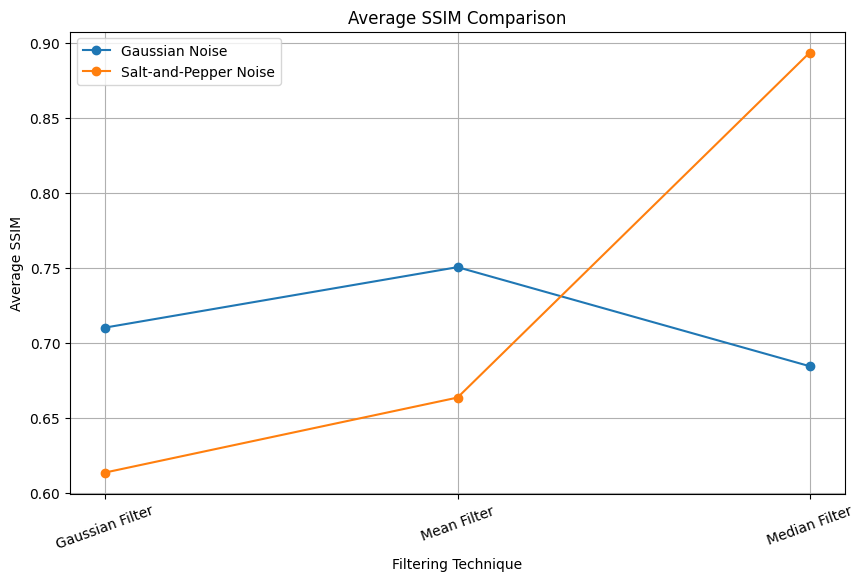

In [33]:
# ==========================================
# FINAL SSIM COMPARISON
# ==========================================

plt.figure(figsize=(10, 6))

for noise_type in average_results["Noise Type"].unique():

    data = average_results[
        average_results["Noise Type"] == noise_type
    ]

    plt.plot(
        data["Filter"],
        data["SSIM"],
        marker="o",
        label=noise_type
    )

plt.title("Average SSIM Comparison")
plt.xlabel("Filtering Technique")
plt.ylabel("Average SSIM")
plt.legend()
plt.xticks(rotation=20)
plt.grid(True)

plt.show()

In [34]:
# ==========================================
# BEST PERFORMING FILTERS
# ==========================================

print("Performance comparison based on PSNR\n")

for noise_type in average_results["Noise Type"].unique():

    data = average_results[
        average_results["Noise Type"] == noise_type
    ]

    best = data.loc[data["PSNR"].idxmax()]

    print("--------------------------------------")
    print("Noise Type:", noise_type)
    print("Filter:", best["Filter"])
    print("Average MSE:", best["MSE"])
    print("Average PSNR:", best["PSNR"])
    print("Average SSIM:", best["SSIM"])

Performance comparison based on PSNR

--------------------------------------
Noise Type: Gaussian Noise
Filter: Gaussian Filter
Average MSE: 82.54
Average PSNR: 29.03
Average SSIM: 0.7102
--------------------------------------
Noise Type: Salt-and-Pepper Noise
Filter: Median Filter
Average MSE: 57.55
Average PSNR: 30.88
Average SSIM: 0.8937


In [35]:
# ==========================================
# SUMMARY TABLE
# ==========================================

summary = average_results.copy()

summary = summary.sort_values(
    ["Noise Type", "PSNR"],
    ascending=[True, False]
)

summary

,Noise Type,Filter,MSE,PSNR,SSIM
0,Gaussian Noise,Gaussian Filter,82.540001,29.03,0.7102
1,Gaussian Noise,Mean Filter,91.800003,28.65,0.7505
2,Gaussian Noise,Median Filter,98.080002,28.34,0.6844
5,Salt-and-Pepper Noise,Median Filter,57.549999,30.88,0.8937
4,Salt-and-Pepper Noise,Mean Filter,124.919998,27.24,0.6635
3,Salt-and-Pepper Noise,Gaussian Filter,136.119995,26.83,0.6135
